In [3]:
from google.colab import files
uploaded = files.upload()

import io
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.cluster import KMeans

summary_df = pd.read_csv(io.BytesIO(next(iter(uploaded.values()))))

summary_df.columns = [col.strip() for col in summary_df.columns]

summary_df = summary_df[['Ticker', 'Average Daily Return', 'Beta', 'Annual Volatility']].copy()

summary_df = summary_df.rename(columns={
    'Average Daily Return': 'Daily_Return',
    'Annual Volatility': 'Annual_Volatility'
})

summary_df = summary_df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

print("Data shape:", summary_df.shape)
display(summary_df.head())

Saving summary_data.csv to summary_data.csv
Data shape: (495, 4)


,Ticker,Daily_Return,Beta,Annual_Volatility
0,A,-0.000002,1.024800,0.296259
1,AAPL,0.000591,1.210689,0.270935
2,ABBV,0.000610,0.299099,0.219958
3,ABNB,0.000074,1.666256,0.467875
4,ABT,-0.000106,0.672317,0.217839


In [4]:
# Features used in Task B / Task C2
features = ['Daily_Return', 'Beta', 'Annual_Volatility']
X = summary_df[features].copy()

# Remove skewness safely (works even if Daily_Return has negative values)
pt = PowerTransformer(method='yeo-johnson', standardize=False)
X_transformed = pt.fit_transform(X)

# Standardise features for k-means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_transformed)

# K-means clustering with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=20)
summary_df['Cluster'] = kmeans.fit_predict(X_scaled)

# Profile clusters
cluster_profile = summary_df.groupby('Cluster')[features].mean()

# Build a simple risk score from Beta + Annual Volatility
cluster_profile['Risk_Score'] = (
    cluster_profile['Beta'].rank(method='dense') +
    cluster_profile['Annual_Volatility'].rank(method='dense')
)

# Order clusters from lowest risk to highest risk
ordered_clusters = cluster_profile.sort_values(
    ['Risk_Score', 'Beta', 'Annual_Volatility']
).index.tolist()

# Assign business labels
cluster_name_map = {
    ordered_clusters[0]: 'Defensive Low-Risk',
    ordered_clusters[1]: 'Stable Core',
    ordered_clusters[2]: 'Moderate Growth',
    ordered_clusters[3]: 'Aggressive High-Risk'
}

summary_df['Cluster_Name'] = summary_df['Cluster'].map(cluster_name_map)

# Use absolute daily return for bubble sizes to avoid plotting issues
summary_df['Return_Magnitude'] = summary_df['Daily_Return'].abs()

# Final cluster summary
final_cluster_summary = summary_df.groupby('Cluster_Name').agg(
    Number_of_Stocks=('Ticker', 'count'),
    Avg_Daily_Return=('Daily_Return', 'mean'),
    Avg_Beta=('Beta', 'mean'),
    Avg_Annual_Volatility=('Annual_Volatility', 'mean')
).round(6)

print("Cluster summary:")
display(final_cluster_summary)

Cluster summary:


,Number_of_Stocks,Avg_Daily_Return,Avg_Beta,Avg_Annual_Volatility
Cluster_Name,,,,
Aggressive High-Risk,62,0.001408,1.607073,0.492926
Defensive Low-Risk,150,0.000301,0.525050,0.223991
Moderate Growth,101,-0.000220,1.174865,0.381962
Stable Core,182,0.000575,0.933995,0.289430


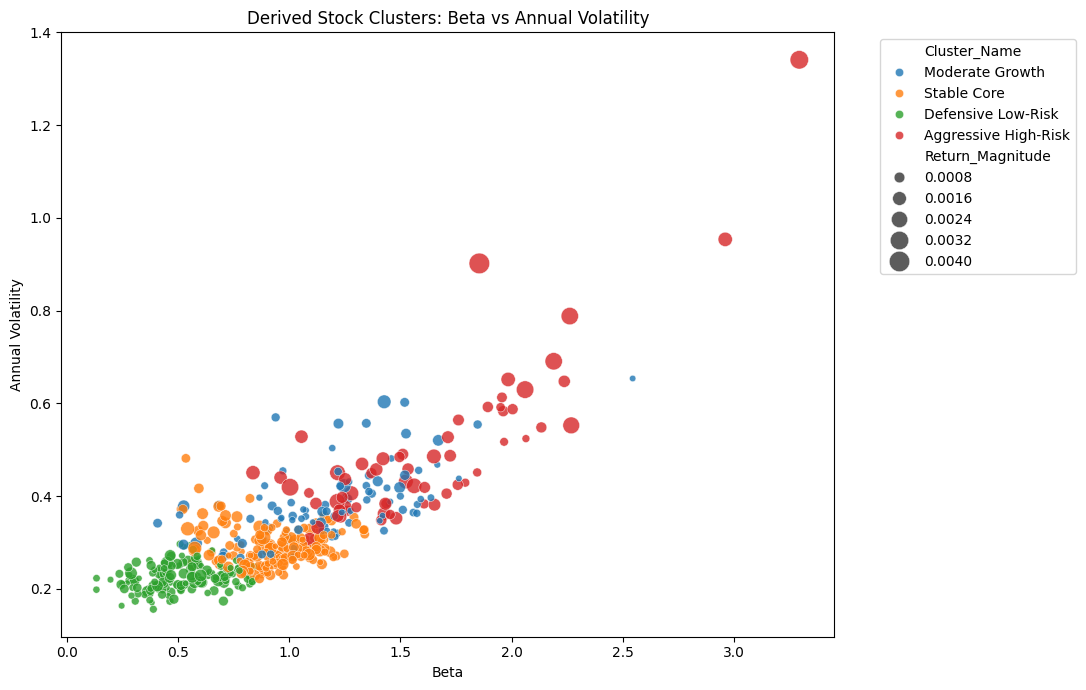

In [5]:
plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=summary_df,
    x='Beta',
    y='Annual_Volatility',
    hue='Cluster_Name',
    size='Return_Magnitude',
    sizes=(20, 220),
    alpha=0.8
)

plt.title('Derived Stock Clusters: Beta vs Annual Volatility')
plt.xlabel('Beta')
plt.ylabel('Annual Volatility')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

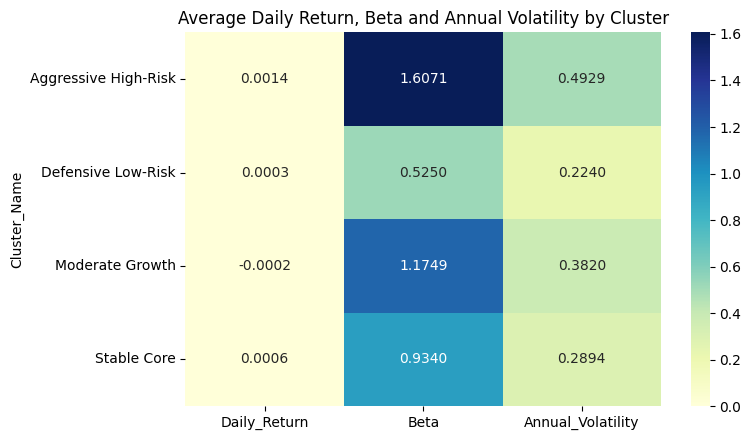

In [6]:
cluster_profile_heatmap = summary_df.groupby('Cluster_Name')[
    ['Daily_Return', 'Beta', 'Annual_Volatility']
].mean()

plt.figure(figsize=(8, 4.5))
sns.heatmap(cluster_profile_heatmap, annot=True, cmap='YlGnBu', fmt='.4f')
plt.title('Average Daily Return, Beta and Annual Volatility by Cluster')
plt.tight_layout()
plt.show()

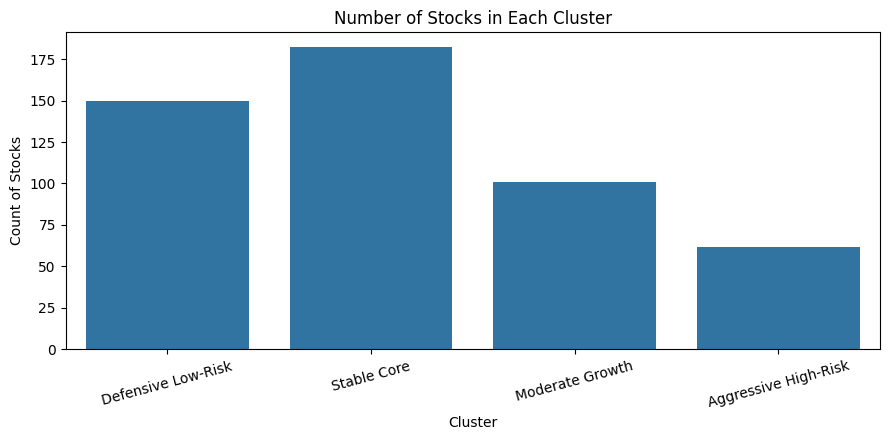

In [7]:
order = [
    'Defensive Low-Risk',
    'Stable Core',
    'Moderate Growth',
    'Aggressive High-Risk'
]

plt.figure(figsize=(9, 4.5))
sns.countplot(data=summary_df, x='Cluster_Name', order=order)
plt.title('Number of Stocks in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count of Stocks')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

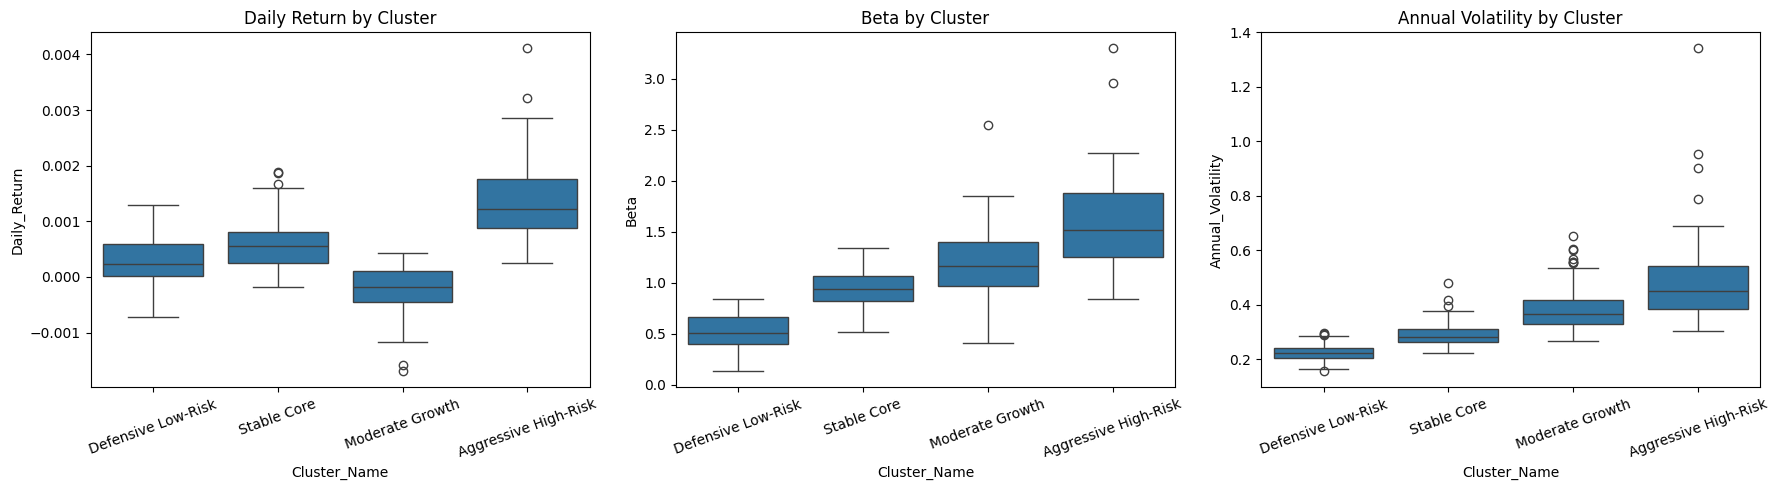

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=summary_df, x='Cluster_Name', y='Daily_Return', order=order, ax=axes[0])
axes[0].set_title('Daily Return by Cluster')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=summary_df, x='Cluster_Name', y='Beta', order=order, ax=axes[1])
axes[1].set_title('Beta by Cluster')
axes[1].tick_params(axis='x', rotation=20)

sns.boxplot(data=summary_df, x='Cluster_Name', y='Annual_Volatility', order=order, ax=axes[2])
axes[2].set_title('Annual Volatility by Cluster')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [9]:
display(final_cluster_summary.sort_index())

,Number_of_Stocks,Avg_Daily_Return,Avg_Beta,Avg_Annual_Volatility
Cluster_Name,,,,
Aggressive High-Risk,62,0.001408,1.607073,0.492926
Defensive Low-Risk,150,0.000301,0.525050,0.223991
Moderate Growth,101,-0.000220,1.174865,0.381962
Stable Core,182,0.000575,0.933995,0.289430
